Load Tagesschau first due to different date format

In [24]:
from pathlib import Path
import pandas as pd

path = Path("/Users/gretawette/Documents/Thesis/data/raw/tagesschau_clean.csv")

df_ts = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip")
df_ts.columns = df_ts.columns.str.replace("\ufeff", "", regex=False).str.strip()  # handles BOM issues

# parse "2025-09-01 00:00:00+02:00" safely
df_ts["Date"] = pd.to_datetime(
    df_ts["Date"].astype(str).str.strip(),
    format="%Y-%m-%d %H:%M:%S%z",
    errors="coerce",
    utc=True
)

# optional: convert to German time, drop tz, keep date-only
df_ts["Date"] = (
    df_ts["Date"]
      .dt.tz_convert("Europe/Berlin")
      .dt.tz_localize(None)
      .dt.normalize()
)

print(df_ts["Date"].dtype)          # datetime64[ns]
print(df_ts["Date"].isna().sum())   # should be low/0
df_ts.head()


datetime64[ns]
0


,Date,Title,Text,source
0,2025-09-01,Deutschland holt zehn afghanische Familien aus...,Zehn afghanische Familien dürfen aus Pakistan ...,Tagesschau
1,2025-10-01,Afghanistan ist wieder online,Handys und Internet funktionieren in Afghanist...,Tagesschau
2,2025-10-24,Äthiopien suspendiert Deutsche-Welle-Journalisten,Die Deutsche Welle darf vorerst nicht mehr dir...,Tagesschau
3,2025-10-02,Mindestens 30 Tote bei Einsturz von Baugerüst,Viele Menschen befanden sich in der Kirche der...,Tagesschau
4,2025-09-30,Brechen afrikanische Exporte in die USA ein?,Seit Jahrzehnten verkaufen mehr als die Hälfte...,Tagesschau


Load all other datasets

In [25]:
from pathlib import Path
import pandas as pd


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent, *cwd.parents):
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw")


PROJECT_ROOT = resolve_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"

file_map = {
    "antispiegel": "antispiegel_clean.csv",
    "compact": "compact_clean.csv",
    "nius": "nius_clean.csv",
    "rt_de": "rt_de_clean.csv",
    # "tagesschau": "tagesschau_clean.csv",
    "tichys": "tichys_clean.csv",
}

datasets = {}
for name, filename in file_map.items():
    path = RAW_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing file for {name}: {path}")
    datasets[name] = pd.read_csv(path)
    print(f"{name:<12} {datasets[name].shape} <- {path}")

# Optional combined corpus dataframe
overall_df = pd.concat(datasets.values(), ignore_index=True)
print("overall_df  ", overall_df.shape)

antispiegel  (589, 4) <- /Users/gretawette/Documents/Thesis/data/raw/antispiegel_clean.csv
compact      (1564, 4) <- /Users/gretawette/Documents/Thesis/data/raw/compact_clean.csv
nius         (3269, 4) <- /Users/gretawette/Documents/Thesis/data/raw/nius_clean.csv
rt_de        (4560, 4) <- /Users/gretawette/Documents/Thesis/data/raw/rt_de_clean.csv
tichys       (2946, 4) <- /Users/gretawette/Documents/Thesis/data/raw/tichys_clean.csv
overall_df   (12928, 4)


In [26]:
overall_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12928 entries, 0 to 12927
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    12928 non-null  object
 1   Title   12928 non-null  object
 2   Text    12927 non-null  object
 3   source  12928 non-null  object
dtypes: object(4)
memory usage: 404.1+ KB


In [27]:
overall_df['source'].value_counts()

source
RT_de              4560
Nius               3269
Tichys_Einblick    2946
Compact            1564
Antispiegel         589
Name: count, dtype: int64

Change dtype of Date to match tagesschau

In [29]:
print(overall_df["Date"].dtype)    

object


In [30]:
overall_df["Date"] = pd.to_datetime(overall_df["Date"], errors="coerce", utc=True)\
                        .dt.tz_localize(None)\
                        .dt.normalize()


In [31]:
print(overall_df["Date"].dtype)  

datetime64[ns]


merge Tagesschau and rest

In [33]:
# Concatenate existing combined dataframe with Tagesschau dataframe
overall_df = pd.concat([overall_df, df_ts], ignore_index=True)

# Quick check
print("overall_df shape:", overall_df.shape)
overall_df["source"].value_counts()

overall_df shape: (19248, 4)


source
Tagesschau         6320
RT_de              4560
Nius               3269
Tichys_Einblick    2946
Compact            1564
Antispiegel         589
Name: count, dtype: int64

In [34]:
# NaN count in Date column
overall_df["Date"].isna().sum()

0

In [3]:
# # Convert Date to datetime in the combined dataframe
# overall_df["Date"] = pd.to_datetime(overall_df["Date"], errors="coerce")

# overall_df["Date"].dtype

dtype('<M8[ns]')

In [35]:
# Add a unique ID column for each row in overall_df
overall_df = overall_df.reset_index(drop=True)
overall_df["row_id"] = overall_df.index + 1

# Optional quick check
print("Unique IDs:", overall_df["row_id"].is_unique)
overall_df[["row_id", "Date", "Title"]].head()

Unique IDs: True


,row_id,Date,Title
0,1,2025-08-01,Bereitet der Westen die Entmachtung oder sogar...
1,2,2025-08-01,EU-Kommission hat Textnachrichten zum Kauf der...
2,3,2025-08-01,Wahlkommission rechtfertigt Einmischung der EU...
3,4,2025-08-02,Fordert Russland wirklich die Vernichtung alle...
4,5,2025-08-02,Der Spiegel macht mal wieder Berichterstattung...


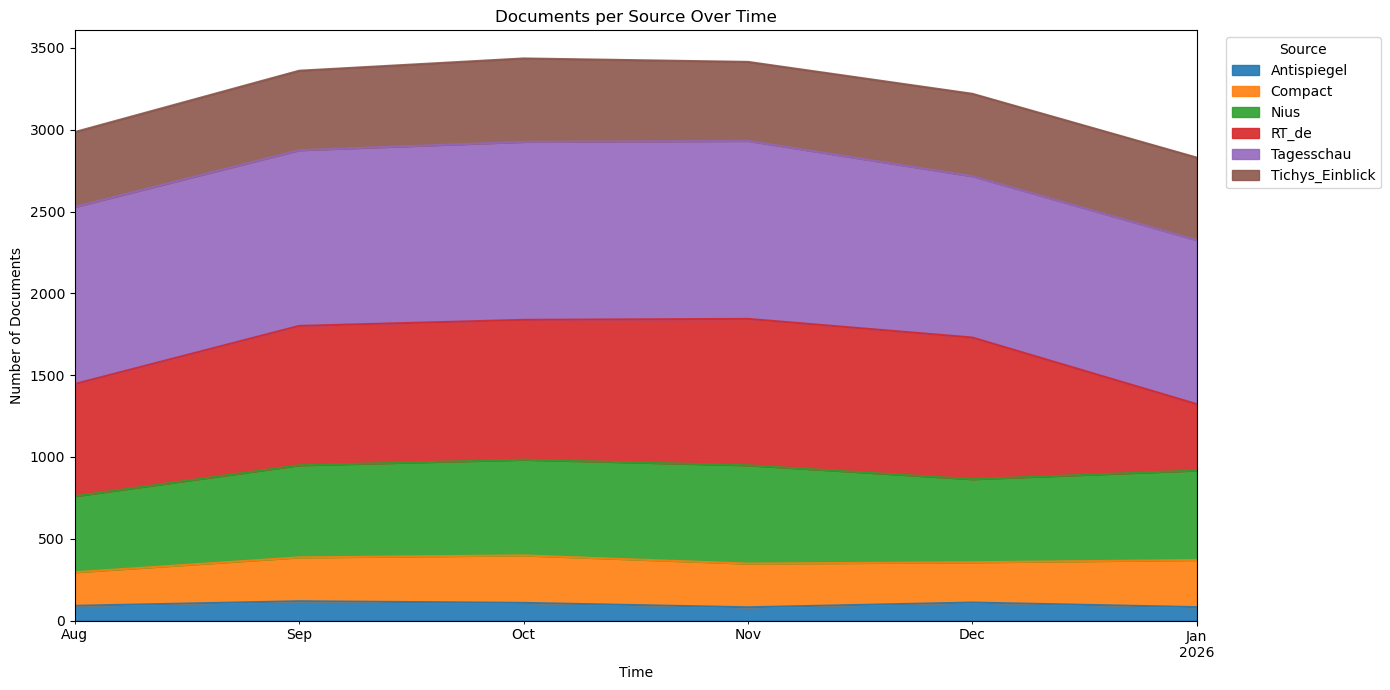

source,Antispiegel,Compact,Nius,RT_de,Tagesschau,Tichys_Einblick
period,,,,,,
2025-08-01,90,205,465,686,1082,458
2025-09-01,118,268,563,852,1074,486
2025-10-01,108,290,585,855,1088,510
2025-11-01,81,267,601,895,1088,483
2025-12-01,110,246,508,866,986,504


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Assumes you already have `overall_df` with columns: Date, source
df_plot = overall_df.copy()

# Parse date and keep valid rows
df_plot["Date"] = pd.to_datetime(df_plot["Date"], errors="coerce", utc=True).dt.tz_localize(None)
df_plot = df_plot.dropna(subset=["Date", "source"])

# Choose granularity: "D" (day), "W" (week), "M" (month)
freq = "M"

# Count docs per source over time
count_df = (
    df_plot
    .assign(period=df_plot["Date"].dt.to_period(freq).dt.to_timestamp())
    .groupby(["period", "source"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Plot stacked area chart
ax = count_df.plot.area(figsize=(14, 7), alpha=0.9)
ax.set_title("Documents per Source Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Number of Documents")
ax.legend(title="Source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

count_df.head()


In [8]:
tmp = overall_df.copy()

# robust parse for mixed timezone formats (important for Tagesschau)
tmp["Date_parsed"] = pd.to_datetime(tmp["Date"], errors="coerce", utc=True)

qc = (
    tmp.groupby("source", dropna=False)
       .agg(
           rows=("Date", "size"),
           parsed_ok=("Date_parsed", lambda s: s.notna().sum()),
           parsed_na=("Date_parsed", lambda s: s.isna().sum()),
           parse_rate=("Date_parsed", lambda s: s.notna().mean()),
           min_date=("Date_parsed", "min"),
           max_date=("Date_parsed", "max"),
       )
       .sort_values("rows", ascending=False)
)

display(qc)


,rows,parsed_ok,parsed_na,parse_rate,min_date,max_date
source,,,,,,
Tagesschau,6320,0,6320,0.0,NaT,NaT
RT_de,4560,4560,0,1.0,2025-08-01 00:00:00+00:00,2026-01-19 00:00:00+00:00
Nius,3269,3269,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
Tichys_Einblick,2946,2946,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
Compact,1564,1564,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
Antispiegel,589,589,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00


In [9]:
display(
    tmp.loc[tmp["source"].str.contains("tagesschau", case=False, na=False),
            ["source", "Date", "Date_parsed"]]
       .head(20)
)


,source,Date,Date_parsed
9982,Tagesschau,NaT,NaT
9983,Tagesschau,NaT,NaT
9984,Tagesschau,NaT,NaT
9985,Tagesschau,NaT,NaT
9986,Tagesschau,NaT,NaT
9987,Tagesschau,NaT,NaT
9988,Tagesschau,NaT,NaT
9989,Tagesschau,NaT,NaT
9990,Tagesschau,NaT,NaT
9991,Tagesschau,NaT,NaT


In [11]:
# 1) Filter mask for Tagesschau rows
mask_ts = overall_df["source"].eq("Tagesschau")

# 2) Parse timezone timestamps and keep only calendar date (as datetime64[ns])
overall_df.loc[mask_ts, "Date"] = (
    pd.to_datetime(overall_df.loc[mask_ts, "Date"], errors="coerce", utc=True)
      .dt.tz_convert("Europe/Berlin")   # optional, German local time
      .dt.tz_localize(None)             # remove timezone -> datetime64[ns]
      .dt.normalize()                   # keep date only (00:00:00)
)

# quick check
print(overall_df.loc[mask_ts, "Date"].head())
print(overall_df.loc[mask_ts, "Date"].dtype)


9982   NaT
9983   NaT
9984   NaT
9985   NaT
9986   NaT
Name: Date, dtype: datetime64[ns]
datetime64[ns]


## BERTopic

In [4]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [5]:
from BERTopic.bertopic_pipeline import run_bertopic_pipeline

In [6]:
from BERTopic.bertopic_config import BERTopicConfig
print(BERTopicConfig().min_df, BERTopicConfig().max_df)


2 0.9


In [7]:
from pathlib import Path
import sys

# from ".../data preprocessing" -> project root ".../Thesis"
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)


cwd: /Users/gretawette/Documents/Thesis/data preprocessing
project root added: /Users/gretawette/Documents/Thesis


In [11]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=overall_df,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="row_id",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 19:04:20,202 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/600 [00:00<?, ?it/s]

2026-03-09 19:07:05,617 - BERTopic - Embedding - Completed ✓
2026-03-09 19:07:05,624 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 19:07:30,013 - BERTopic - Dimensionality - Completed ✓
2026-03-09 19:07:30,015 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 19:07:32,942 - BERTopic - Cluster - Completed ✓
2026-03-09 19:07:32,951 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 19:07:48,055 - BERTopic - Representation - Completed ✓


In [13]:
overall_df

,Date,Title,Text,source,row_id
0,2025-08-01,Bereitet der Westen die Entmachtung oder sogar...,Der Streit um das Nationale Anti-Korruptionsbü...,Antispiegel,1
1,2025-08-01,EU-Kommission hat Textnachrichten zum Kauf der...,Die New York Times versucht seit langem vor Ge...,Antispiegel,2
2,2025-08-01,Wahlkommission rechtfertigt Einmischung der EU...,Ende September stehen in Moldawien Parlamentsw...,Antispiegel,3
3,2025-08-02,Fordert Russland wirklich die Vernichtung alle...,Ich bin auf die Geschichte zuerst bei RT-DE ge...,Antispiegel,4
4,2025-08-02,Der Spiegel macht mal wieder Berichterstattung...,"Wer auch nicht-westliche Medien liest, der ist...",Antispiegel,5
...,...,...,...,...,...
19243,2026-01-31,Birmingham: Verurteilter Islam-Terrorist will ...,„Ich habe ein sehr abwechslungsreiches Leben h...,Tichys_Einblick,19244
19244,2026-01-31,Migrantische Gewalt: Die Realitätsleugnung geh...,„Warum gibt es hierzulande keine Schutzmaßnahm...,Tichys_Einblick,19245
19245,2026-01-31,"Heute ist der Fleißige der Dumme, aber die Dum...",Den Deutschen mangelt es an Fleiß. „Lifestyle-...,Tichys_Einblick,19246
19246,2026-01-31,Bluttat in Hamburgs U-Bahn: Südsudanese war po...,Gegen 22.07 Uhr ereignete sich am belebten U-B...,Tichys_Einblick,19247


In [12]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7279,-1_russland_ukraine_afd_merz,"[russland, ukraine, afd, merz, russischen, spd...",[Man muss den russischen Forderungen nicht zus...
1,0,988,0_israel_hamas_gaza_gazastreifen,"[israel, hamas, gaza, gazastreifen, geiseln, i...",[In Israel versammeln sich Tausende zum Gedenk...
2,1,541,1_ukraine_putin_selenskyj_russland,"[ukraine, putin, selenskyj, russland, präsiden...","[Die EU-Außenbeauftragte Kallas hat betont, di..."
3,2,417,2_q10_vitamin_entzündungen_patienten,"[q10, vitamin, entzündungen, patienten, stress...",[Immer mehr Studien bestätigen: Es ist das wir...
4,3,331,3_polizei_mann_jährige_täter,"[polizei, mann, jährige, täter, tat, messer, j...",[Im grandiosen Film „Eine Frage der Ehre“ fass...
5,4,292,4_venezuela_maduro_venezuelas_karibik,"[venezuela, maduro, venezuelas, karibik, venez...",[Dass die USA mindestens sieben mit Marschflug...
6,5,246,5_migranten_asyl_migration_asylbewerber,"[migranten, asyl, migration, asylbewerber, flü...",[# Definition von „sicheren Herkunftsstaaten“:...
7,6,228,6_wirtschaft_unternehmen_industrie_wachstum,"[wirtschaft, unternehmen, industrie, wachstum,...",[Mehrere führende Wirtschaftsinstitute blicken...
8,7,188,7_wegner_berlin_berliner_stromausfall,"[wegner, berlin, berliner, stromausfall, strom...",[Die vergangenen fünf Tage offenbarten die anf...
9,8,183,8_kirk_charlie_charlie kirk_kirks,"[kirk, charlie, charlie kirk, kirks, utah, mor...",[# „Trump predigt: Hasse deine Feinde”: Wie de...


In [14]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=overall_df,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=15, hdbscan_min_samples=7),
    id_col="row_id"
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 19:18:35,808 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/600 [00:00<?, ?it/s]

2026-03-09 19:21:49,224 - BERTopic - Embedding - Completed ✓
2026-03-09 19:21:49,231 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 19:22:07,305 - BERTopic - Dimensionality - Completed ✓
2026-03-09 19:22:07,313 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-09 19:22:11,013 - BERTopic - Cluster - Completed ✓
2026-03-09 19:22:11,110 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-09 19:22:32,883 - BERTopic - Representation - Completed ✓


In [15]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7615,-1_ukraine_russland_trump_euro,"[ukraine, russland, trump, euro, afd, merz, ru...",[Diese Ansprache ist Zeitgeschichte. Ein US-Pr...
1,0,439,0_q10_patienten_vitamin_entzündungen,"[q10, patienten, vitamin, entzündungen, stress...",[Entzündungen sind kein Randphänomen – sie sin...
2,1,293,1_polizei_mann_täter_jährige,"[polizei, mann, täter, jährige, tat, messer, j...","[# Neue Details zum Tag, an dem Liana ermordet..."
3,2,242,2_migranten_asyl_migration_asylbewerber,"[migranten, asyl, migration, asylbewerber, flü...","[Seit Merkels Satz ""Wir schaffen das"" vor zehn..."
4,3,199,3_günther_zdf_lanz_journalisten,"[günther, zdf, lanz, journalisten, öffentlich,...","[# Krasse Kritik, keine Wende, nähern sich ARD..."
5,4,193,4_wegner_berliner_berlin_stromausfall,"[wegner, berliner, berlin, stromausfall, strom...",[Für die Bewohner des Berliner Südens startete...
6,5,183,5_kirk_charlie_charlie kirk_kirks,"[kirk, charlie, charlie kirk, kirks, utah, mor...",[# Mord an Charlie Kirk: Die Foto-Chronik des ...
7,6,182,6_merz_friedrich merz_friedrich_kanzler,"[merz, friedrich merz, friedrich, kanzler, cdu...",[# Entweder bald Schwarz-Blau – oder irgendwan...
8,7,171,7_autos_porsche_vw_mercedes,"[autos, porsche, vw, mercedes, volkswagen, ele...",[In einem Gespräch mit Bloomberg adressiert de...
9,8,171,8_vermögenswerte_belgien_ukraine_euroclear,"[vermögenswerte, belgien, ukraine, euroclear, ...",[Die EU denkt schon seit dem Beginn der Eskala...


## BERTopic per class

In [ ]:
from bertopic import BERTopic

# 1) Prepare docs + classes
# Assumes your merged dataframe is `overall_df` and has columns: Text, source
df_tpc = overall_df[["Text", "source"]].dropna().copy()


docs = df_tpc["Text"].tolist()
classes = df_tpc["source"].tolist()

print("Docs:", len(docs))
print("Classes:", df_tpc["source"].value_counts().to_dict())

# 2) Global topic model (across all docs)
topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(docs)

# 3) Topics per class (source)
topics_per_class = topic_model.topics_per_class(docs, classes=classes)

# 4) Visualize
fig = topic_model.visualize_topics_per_class(topics_per_class, top_n_topics=10)
fig.show()

# Optional: inspect table
topics_per_class.head(20)


2026-03-09 19:24:10,672 - BERTopic - Embedding - Transforming documents to embeddings.


Docs: 19246
Classes: {'Tagesschau': 6319, 'RT_de': 4559, 'Nius': 3269, 'Tichys_Einblick': 2946, 'Compact': 1564, 'Antispiegel': 589}


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/602 [00:00<?, ?it/s]

2026-03-09 19:27:46,631 - BERTopic - Embedding - Completed ✓
2026-03-09 19:27:46,642 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-09 19:27:53,922 - BERTopic - Dimensionality - Completed ✓
2026-03-09 19:27:53,945 - BERTopic - Cluster - Start clustering the reduced embeddings
